# Problem 3.1

**Integrated Energy Grids**

**Problem 3.1. Joint capacity and dispatch optimisation and limiting $CO_2$ emissions**

**Optimise the capacity and dispatch of solar PV, onshore wind, and open-cycle gas turbine (OCGT) generators to supply the inelastic electricity demand throughout one year.**

**To do this, take the time series for the wind and solar capacity factors for Portugal in 2015 obtained from https://zenodo.org/record/3253876#.XSiVOEdS8l0 and https://zenodo.org/record/2613651#.X0kbhDVS-uV (select the file ‘pvoptimal.csv’) and the electricity demand from https://github.com/aleks-g/integrated-energy-grids/tree/main/integrated-energy-grids/Problems/data.**

**Consider the annualised capital costs and marginal generation costs for the different technologies in Table 1. The efficiency for the OCGT plant is 0.41..**

**a) Calculate the total system cost, the optimal installed capacities, the annual generation per technology, and plot the hourly generation and demand during January.**

**b) Calculate the revenues collected by every technology throughout the year and show that their sum is equal to their costs.**

:::{note}
If you have not yet set up Python on your computer, you can execute this tutorial in your browser via [Google Colab](https://colab.research.google.com/). Click on the rocket in the top right corner and launch "Colab". If that doesn't work download the `.ipynb` file and import it in [Google Colab](https://colab.research.google.com/).

Then install `pandas` and `numpy` by executing the following command in a Jupyter cell at the top of the notebook.

```sh
!pip install pandas pypsa
```
:::

:::{note}
See also https://model.energy.
:::

In this exercise, we want to build a replica of [model.energy](https://model.energy). This tool calculates the cost of meeting a constant electricity demand from a combination of wind power, solar power and storage for different regions of the world. We deviate from [model.energy](https://model.energy) by including electricity demand profiles rather than a constant electricity demand. 

In [1]:
import os

# Change to your project root
os.chdir(r'c:\Users\User\OneDrive\Documents\DTU\46770 - Integrated energy grids\DTU-Course---Integrated-Energy-Grids\presentation_group_7')

# Verify it worked
print(os.getcwd())

c:\Users\User\OneDrive\Documents\DTU\46770 - Integrated energy grids\DTU-Course---Integrated-Energy-Grids\presentation_group_7


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

In [3]:
import matplotlib as mpl
from cycler import cycler

# ── Brand palette: Deep Blue + Amber (all shades) ────────────────────────────
BLUE  = {"dark": "#1E3A5F", "mid": "#2563EB", "light": "#60A5FA", "pale": "#BFDBFE"}
AMBER = {"dark": "#92400E", "mid": "#D97706", "light": "#FBBF24", "pale": "#FDE68A"}

TECH_COLORS = {
    "onwind":          BLUE["mid"],    # vivid blue  – wind
    "solar":           AMBER["light"], # golden amber – solar
    "OCGT":            BLUE["dark"],   # dark navy   – peaker gas
    "CCGT":            AMBER["mid"],   # medium amber – base gas
    "battery storage": BLUE["light"],  # sky blue    – battery
    "demand":          "#E2E8F0",      # near-white  – demand line
}

# ── Dark-slide theme globals ──────────────────────────────────────────────────
BG      = "#0F172A"  # figure / slide background
PLOT_BG = "#1E293B"  # axes area background
TEXT    = "#E2E8F0"  # all text (titles, labels, ticks)
GRID    = "#334155"  # subtle grid
SPINE   = "#475569"  # axis borders

mpl.rcParams.update({
    "figure.facecolor":  BG,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.facecolor": BG,
    "axes.facecolor":    PLOT_BG,
    "axes.edgecolor":    SPINE,
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlecolor":   TEXT,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "axes.titlepad":     14,
    "axes.labelcolor":   TEXT,
    "axes.labelsize":    11,
    "axes.labelpad":     8,
    "axes.prop_cycle":   cycler(color=list(TECH_COLORS.values())),
    "grid.color":        GRID,
    "grid.linewidth":    0.6,
    "grid.alpha":        1.0,
    "xtick.color":       TEXT,
    "ytick.color":       TEXT,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "legend.facecolor":  PLOT_BG,
    "legend.edgecolor":  SPINE,
    "legend.labelcolor": TEXT,
    "legend.fontsize":   10,
    "legend.framealpha": 0.95,
    "legend.frameon":    True,
    "lines.linewidth":   1.8,
    "font.family":       "sans-serif",
    "font.size":         11,
    "text.color":        TEXT,
})

print("Dark-slide theme ready.  Brand colours:", list(TECH_COLORS.keys()))


Dark-slide theme ready.  Brand colours: ['onwind', 'solar', 'OCGT', 'CCGT', 'battery storage', 'demand']


## Prerequisites: handling technology data and costs

We maintain a database (https://github.com/PyPSA/technology-data) which collects assumptions and projections for energy system technologies (such as costs, efficiencies, lifetimes, etc.) for given years, which we can load into a `pandas.DataFrame`. This requires some pre-processing to load (e.g. converting units, setting defaults, re-arranging dimensions):

In [4]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [5]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]


Let's also write a small utility function that calculates the **annuity** to annualise investment costs. The formula is

$$
a(r, n) = \frac{r}{1-(1+r)^{-n}}
$$
where $r$ is the discount rate and $n$ is the lifetime.

In [6]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [7]:
annuity(0.07, 20)

0.09439292574325567

Based on this, we can calculate the marginal generation costs (€/MWh):

In [8]:
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

and the annualised investment costs (`capital_cost` in PyPSA terms, €/MW/a):

In [9]:
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

In [10]:
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

We can now read the capital and marginal cost of onshore wind, solar and OCGT

In [11]:
costs.at["onwind", "capital_cost"] #EUR/MW/a

np.float64(128306.33032200082)

In [12]:
costs.at["solar", "capital_cost"] #EUR/MW/a

np.float64(64560.14335577917)

In [13]:
costs.at["OCGT", "capital_cost"] #EUR/MW/a

np.float64(60235.71932395716)

In [14]:
costs.at["OCGT", "marginal_cost"] #EUR/MWh

np.float64(75.31792926829269)

## Retrieving time series data

In this example, wind data from [https://zenodo.org/record/3253876#.XSiVOEdS8l0](https://zenodo.org/record/3253876#.XSiVOEdS8l0) and solar PV data from [https://zenodo.org/record/2613651#.X0kbhDVS-uV](https://zenodo.org/record/3253876#.XSiVOEdS8l0) is used. The data is downloaded in csv format and saved in the 'data' folder.
The Pandas package is used as a convenient way of managing the datasets.

For convenience, the column including date information is converted into Datetime and set as index

In [15]:
data_solar = pd.read_csv('data/pv_optimal.csv',sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv',sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv',sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

The data format can now be analyzed using the .head() function to show the first lines of the data set

In [16]:
data_solar.head()

,utc_time,AUT,BEL,BGR,BIH,CHE,CYP,CZE,DEU,DNK,...,MLT,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
utc_time,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00+00:00,1979-01-01T00:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 01:00:00+00:00,1979-01-01T01:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 02:00:00+00:00,1979-01-01T02:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 03:00:00+00:00,1979-01-01T03:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 04:00:00+00:00,1979-01-01T04:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We will use timeseries for Portugal in this excercise

In [17]:
country = 'PRT'

### Joint capacity and dispatch optimization

For building the model, we start again by initialising an empty network, adding the snapshots, and the electricity bus.

In [18]:
n = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

n.set_snapshots(hours_in_2015.values)

n.add("Bus",
            "electricity")

n.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 14:00:00', '2015-12-31 15:00:00',
               '2015-12-31 16:00:00', '2015-12-31 17:00:00',
               '2015-12-31 18:00:00', '2015-12-31 19:00:00',
               '2015-12-31 20:00:00', '2015-12-31 21:00:00',
               '2015-12-31 22:00:00', '2015-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=8760, freq=None)

We add all the technologies we are going to include as carriers. Defining carriers is not mandatory but will ease plotting and assigning emissions of CO2 in future steps. 

In [19]:
carriers = [
    "onwind",
    "solar",
    "OCGT",
    "CCGT",
    "battery storage",
]

n.add(
    "Carrier",
    carriers,
    color=[
        TECH_COLORS["onwind"],
        TECH_COLORS["solar"],
        TECH_COLORS["OCGT"],
        TECH_COLORS["CCGT"],
        TECH_COLORS["battery storage"],
    ],
    co2_emissions=[costs.at[c, "CO2 intensity"] for c in carriers],
)


Next, we add the demand time series to the model.

In [20]:
# add load to the bus
n.add("Load",
      "demand",
      bus="electricity",
      p_set=data_el[country].values)

Let's have a check whether the data was read-in correctly.

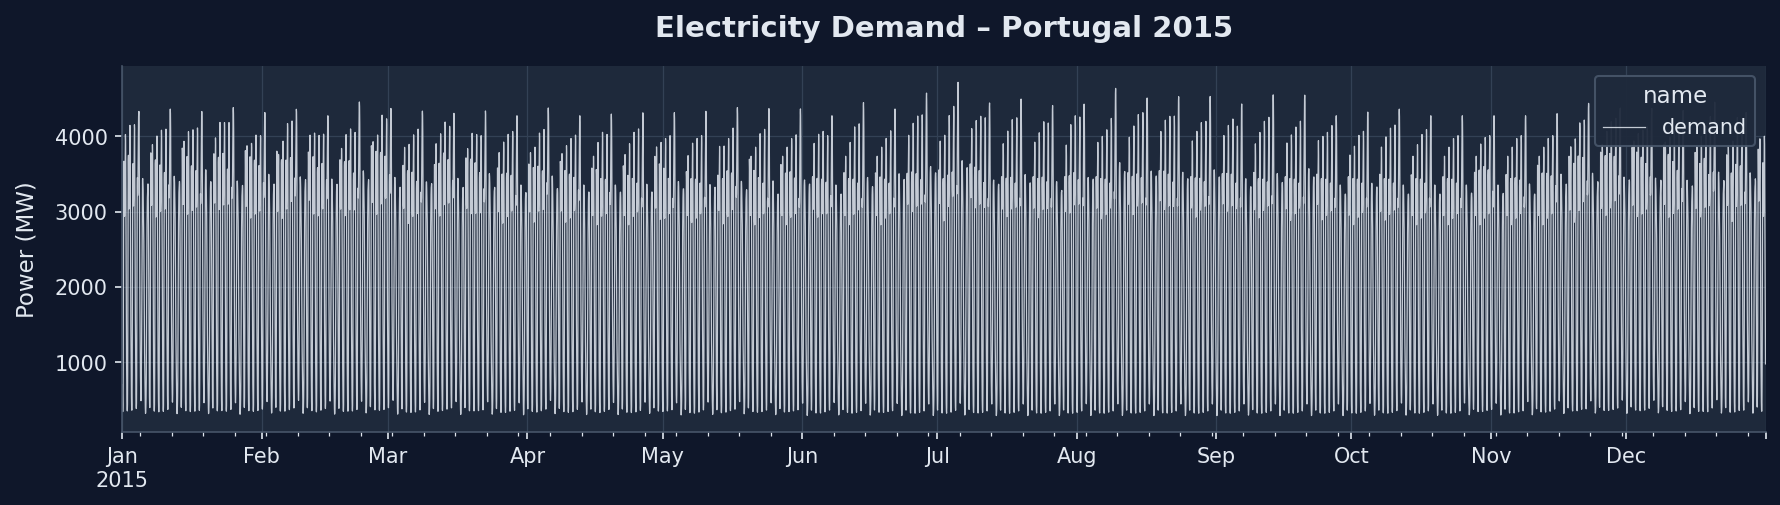

In [21]:
fig, ax = plt.subplots(figsize=(12, 3.5))
n.loads_t.p_set.plot(ax=ax, color=TECH_COLORS["demand"], linewidth=0.6, alpha=0.85)
ax.set_title("Electricity Demand – Portugal 2015")
ax.set_ylabel("Power (MW)")
ax.set_xlabel("")
fig.tight_layout()
plt.show()


We now add the generators and set up their capacities to be extendable so that they can be optimized together with the dispatch time series. For the wind and solar generator, we need to indicate the capacity factor or maximum power per unit 'p_max_pu'

In [22]:
n.add(
    "Generator",
    "OCGT",
    bus="electricity",
    carrier="OCGT",
    capital_cost=47718,
    marginal_cost=64.7,
    efficiency=0.41,
    p_nom_extendable=True,
)

CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "onwind",
        bus="electricity",
        carrier="onwind",
        p_max_pu=CF_wind.values,
        capital_cost=101644,
        marginal_cost=0,
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "solar",
        bus="electricity",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=51346,
        marginal_cost=0,
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

So let's make sure the capacity factors are read-in correctly.

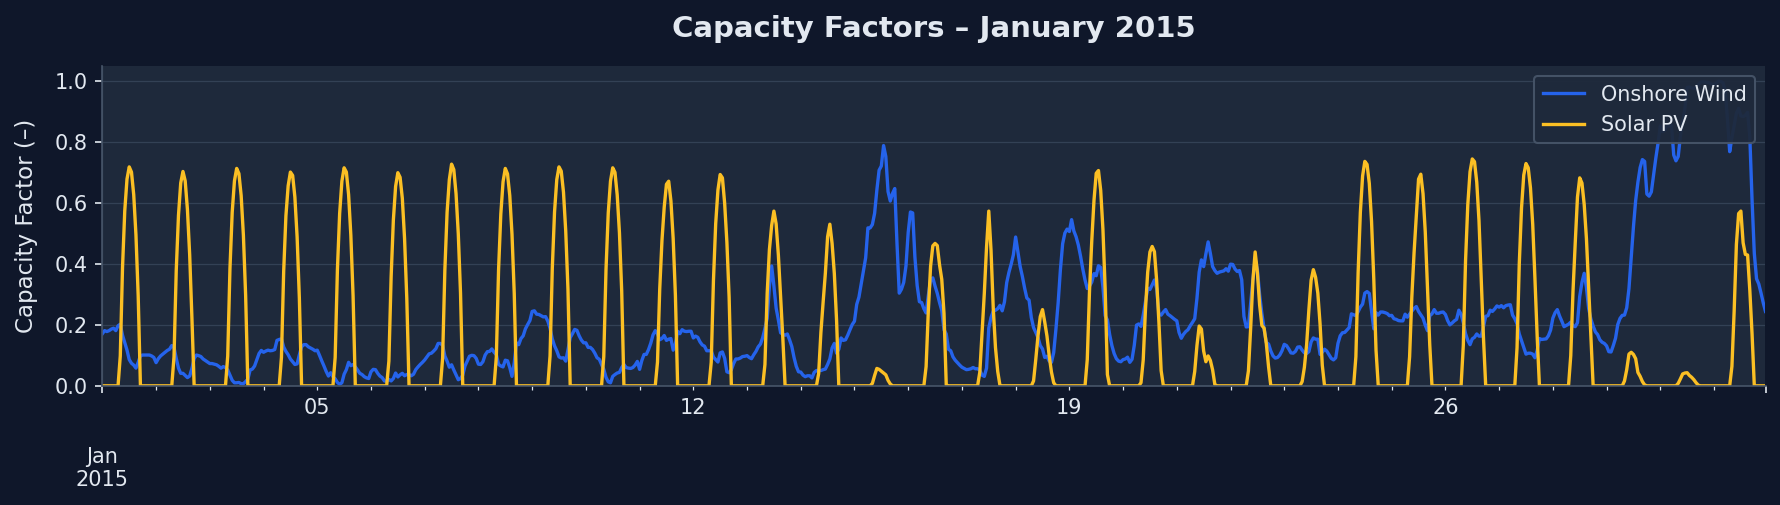

In [23]:
fig, ax = plt.subplots(figsize=(12, 3.5))
cf = n.generators_t.p_max_pu.loc["2015-01"]
for col, color, label in [
    ("onwind", TECH_COLORS["onwind"], "Onshore Wind"),
    ("solar",  TECH_COLORS["solar"],  "Solar PV"),
]:
    if col in cf.columns:
        cf[col].plot(ax=ax, color=color, linewidth=1.6, label=label)
ax.set_title("Capacity Factors – January 2015")
ax.set_ylabel("Capacity Factor (–)")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


### Model Run

We can already solved the model using the open-solver "highs" or the commercial solver "gurobi" with the academic license

In [24]:
n.optimize(solver_name="highs")

C:\Users\User\AppData\Local\Temp\ipykernel_19800\3144390136.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['electricity'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 70.86it/s]
INFO:linopy.io: Writing time: 0.55s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 1.24e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the netwo

('ok', 'optimal')

Now, we can look at the results and evaluate the total system cost (in billion Euros per year)

In [25]:
n.objective / 1e9

1.2368001353196827

The optimised capacities in GW:

In [26]:
n.generators.p_nom_opt.div(1e3)  # MW -> GW

name
OCGT      4.381392
onwind    1.506215
solar     4.968183
Name: p_nom_opt, dtype: float64

The total energy generation by technology in TWh:

In [27]:
n.generators_t.p.sum().div(1e6)  # MWh -> TWh

name
OCGT      9.575501
onwind    2.708016
solar     7.164058
dtype: float64

We can plot the dispatch of every generator thoughout January

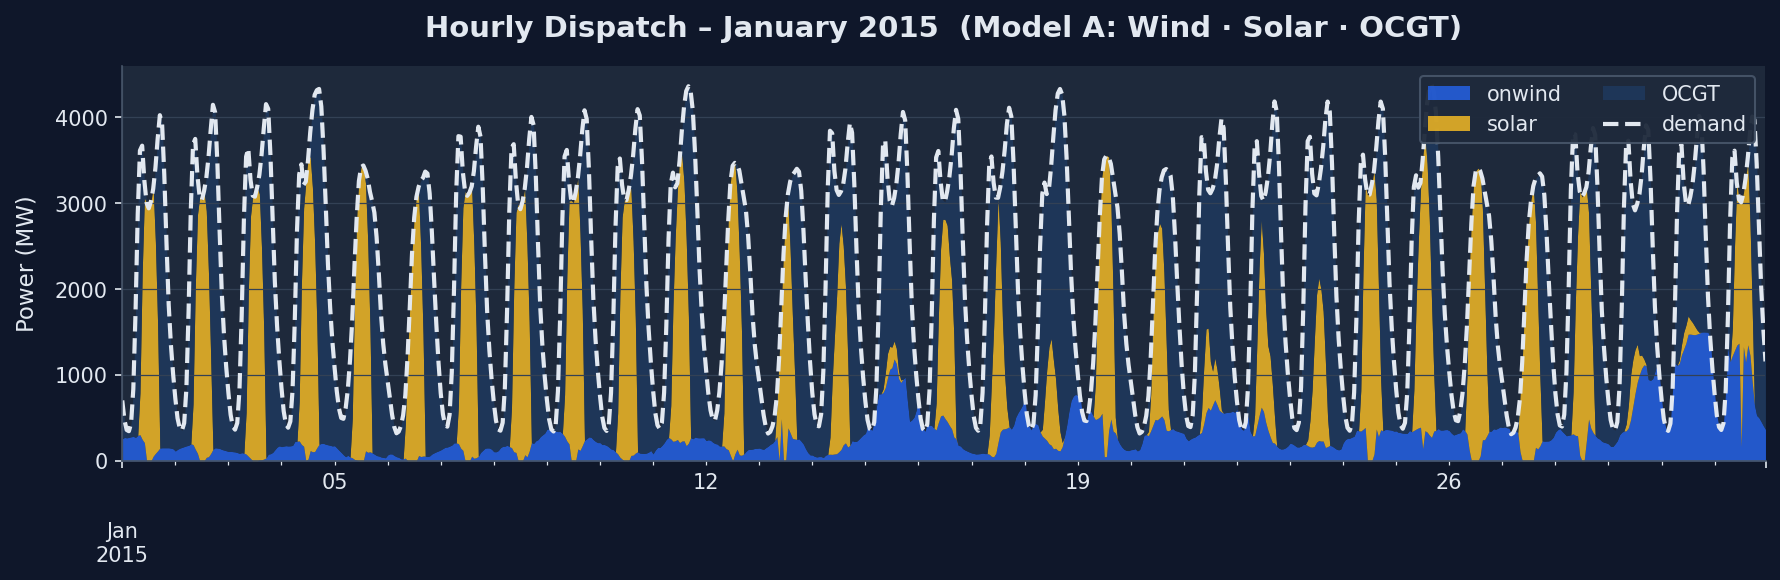

In [28]:
fig, ax = plt.subplots(figsize=(12, 4))
dispatch = n.generators_t.p.loc["2015-01"]
_pref = ["onwind", "solar", "OCGT"]
col_order = [c for c in _pref if c in dispatch.columns]
col_order += [c for c in dispatch.columns if c not in col_order]
colors = [TECH_COLORS.get(c, "#888888") for c in col_order]
dispatch[col_order].plot.area(ax=ax, color=colors, alpha=0.82, linewidth=0)
n.loads_t.p_set.loc["2015-01"].plot(
    ax=ax, color=TECH_COLORS["demand"], linewidth=2, linestyle="--", label="Demand"
)
ax.set_title("Hourly Dispatch – January 2015  (Model A: Wind · Solar · OCGT)")
ax.set_ylabel("Power (MW)")
ax.set_xlabel("")
ax.legend(loc="upper right", ncol=2)
fig.tight_layout()
plt.show()


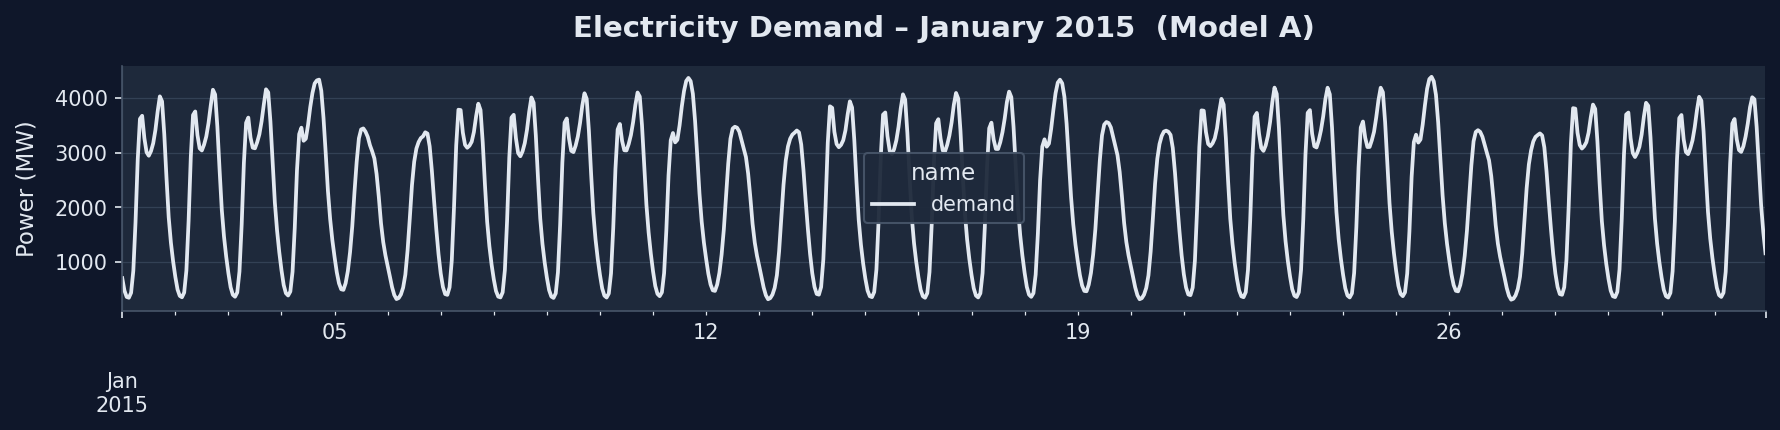

In [29]:
fig, ax = plt.subplots(figsize=(12, 3))
n.loads_t.p.loc["2015-01"].plot(ax=ax, color=TECH_COLORS["demand"], linewidth=1.8)
ax.set_title("Electricity Demand – January 2015  (Model A)")
ax.set_ylabel("Power (MW)")
ax.set_xlabel("")
fig.tight_layout()
plt.show()


**b) Calculate the revenues collected by every technology throughout the year and show that their sum is equal to their costs.**

To calculate the revenues collected by every technology, we multiply the energy generated in every hour by the electricity price in that hour and sum for the entire year.

In [30]:
n.generators_t.p.multiply(n.buses_t.marginal_price.to_numpy()).sum().div(1e6) # EUR -> MEUR

name
OCGT      828.606159
onwind    153.097670
solar     255.096306
dtype: float64

This corresponds to the total cost for every technology, which we can also read using the statistics module:

In [31]:
(n.statistics.capex() + n.statistics.opex()).div(1e6)

component  carrier
Generator  OCGT       828.606159
           onwind            NaN
           solar             NaN
dtype: float64

**Now we are adding the possibility of installing battery storage. The annualised capital cost of the battery comprises 12,894 EUR/MWh/a for the energy capacity and 24,678 EUR/MW/a for the inverter. The inverter efficiency is 0.96 and the battery is assumed to have a fixed energy-to-power ratio of 2 hours. Assume also an existing combined-cycle gas turbine (CCGT) unit with an electricity generation capacity of 6 GW and efficiency of 0.58. The annualised capital cost and marginal generation costs for the CCGT are respectively 104,788 EUR/MW/a and 46.8 EUR/MWh.**

**c) Calculate the total system cost, the optimal installed capacities, the annual generation per technology, and plot the hourly generation and demand during January.**

Let's build the model from scratch to include the battery storage and the CCGT generator.

In [32]:
costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

In [33]:
n = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

n.set_snapshots(hours_in_2015.values)

n.add("Bus",
            "electricity")

n.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 14:00:00', '2015-12-31 15:00:00',
               '2015-12-31 16:00:00', '2015-12-31 17:00:00',
               '2015-12-31 18:00:00', '2015-12-31 19:00:00',
               '2015-12-31 20:00:00', '2015-12-31 21:00:00',
               '2015-12-31 22:00:00', '2015-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=8760, freq=None)

We add all the technologies we are going to include as carriers. Defining carriers is not mandatory but will ease plotting and assigning emissions of CO2 in future steps. 

In [34]:
carriers = [
    "onwind",
    "solar",
    "OCGT",
    "CCGT",
    "battery storage",
]

n.add(
    "Carrier",
    carriers,
    color=[
        TECH_COLORS["onwind"],
        TECH_COLORS["solar"],
        TECH_COLORS["OCGT"],
        TECH_COLORS["CCGT"],
        TECH_COLORS["battery storage"],
    ],
    co2_emissions=[costs.at[c, "CO2 intensity"] for c in carriers],
)


Next, we add the demand time series to the model.

In [35]:
# add load to the bus
n.add("Load",
      "demand",
      bus="electricity",
      p_set=data_el[country].values)

Let's have a check whether the data was read-in correctly.

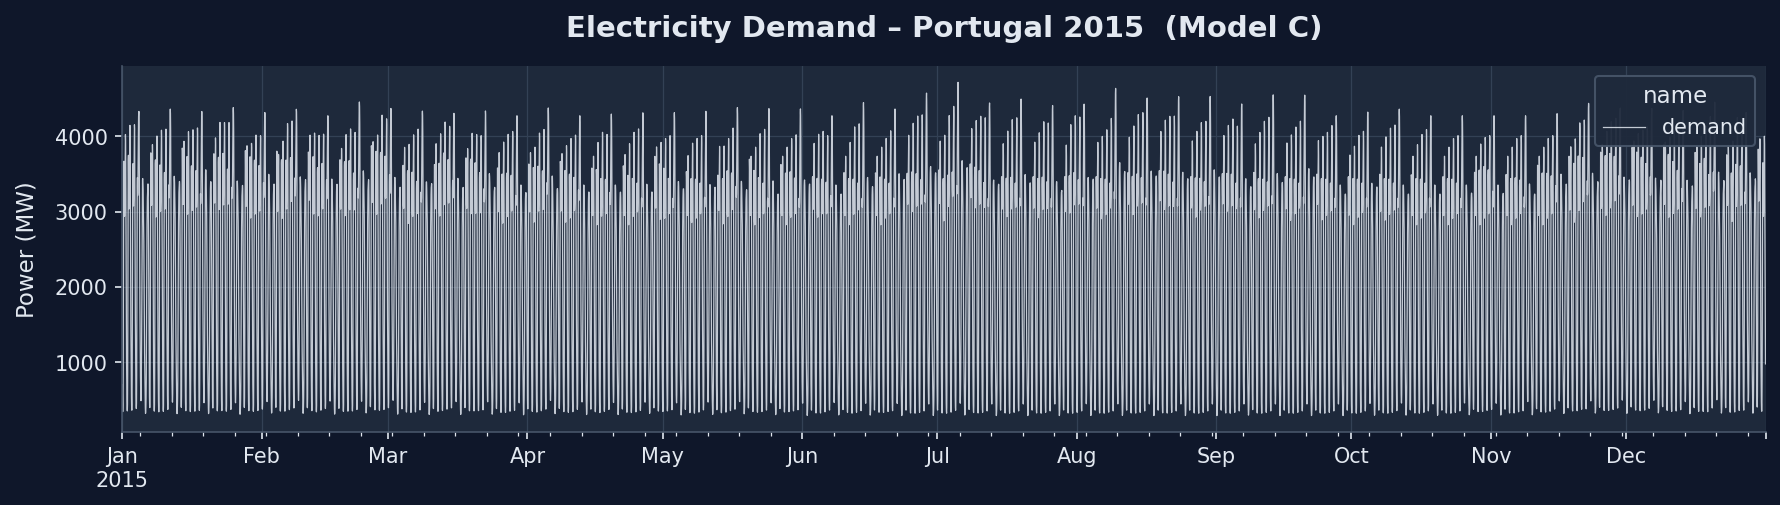

In [36]:
fig, ax = plt.subplots(figsize=(12, 3.5))
n.loads_t.p_set.plot(ax=ax, color=TECH_COLORS["demand"], linewidth=0.6, alpha=0.85)
ax.set_title("Electricity Demand – Portugal 2015  (Model C)")
ax.set_ylabel("Power (MW)")
ax.set_xlabel("")
fig.tight_layout()
plt.show()


We add now the generators and set up their capacities to be extendable so that they can be optimized together with the dispatch time series. For the wind and solar generator, we need to indicate the capacity factor or maximum power per unit 'p_max_pu'

In [37]:
n.add(
    "Generator",
    "OCGT",
    bus="electricity",
    carrier="OCGT",
    capital_cost=costs.at["OCGT", "capital_cost"],
    marginal_cost=costs.at["OCGT", "marginal_cost"],
    efficiency=costs.at["OCGT", "efficiency"],
    p_nom_extendable=True,
)

CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "onwind",
        bus="electricity",
        carrier="onwind",
        p_max_pu=CF_wind.values,
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
n.add(
        "Generator",
        "solar",
        bus="electricity",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

So let's make sure the capacity factors are read-in correctly.

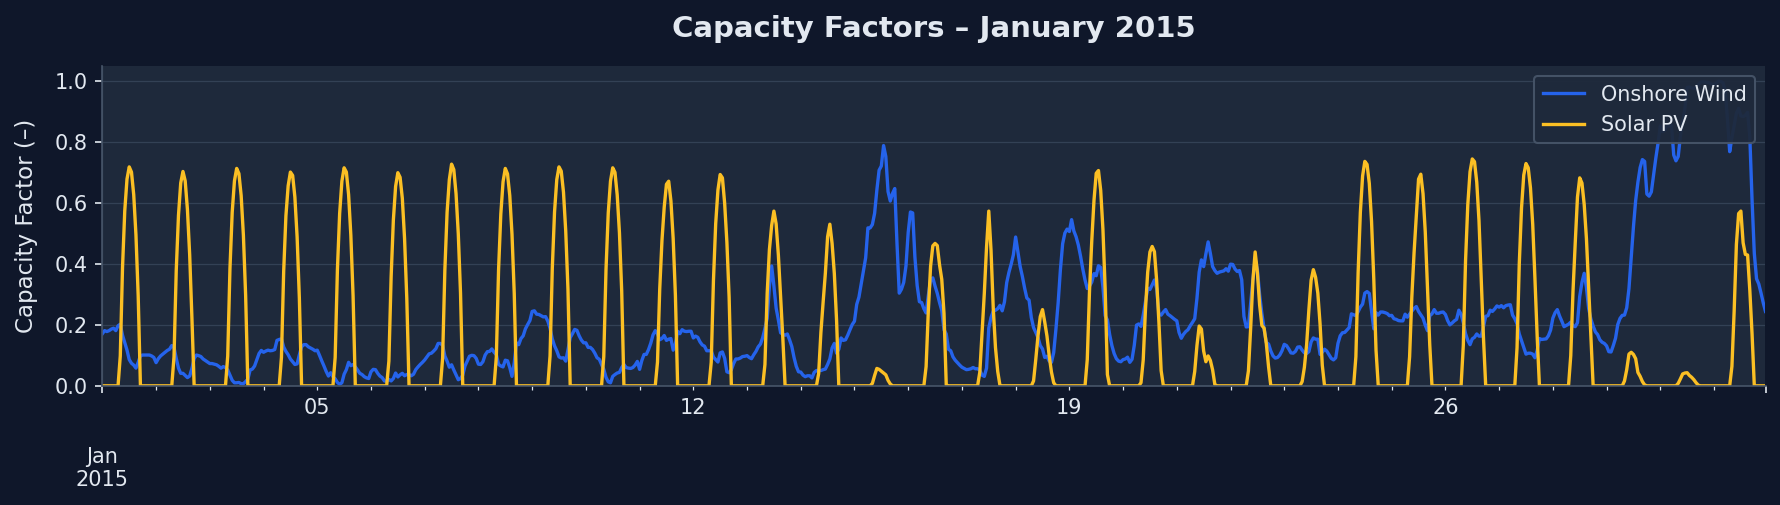

In [38]:
fig, ax = plt.subplots(figsize=(12, 3.5))
cf = n.generators_t.p_max_pu.loc["2015-01"]
for col, color, label in [
    ("onwind", TECH_COLORS["onwind"], "Onshore Wind"),
    ("solar",  TECH_COLORS["solar"],  "Solar PV"),
]:
    if col in cf.columns:
        cf[col].plot(ax=ax, color=color, linewidth=1.6, label=label)
ax.set_title("Capacity Factors – January 2015")
ax.set_ylabel("Capacity Factor (–)")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


We add the battery storage, assuming a fixed energy-to-power ratio of 2 hours, i.e. if fully charged, the battery can discharge at full capacity for 2 hours. 

For the capital cost, we have to factor in both the capacity and energy cost of the storage. 

We include the charging and discharging efficiencies we enforce a cyclic state-of-charge condition, i.e. the state of charge at the beginning of the optimisation period must equal the final state of charge.

In [53]:
n.add(
    "StorageUnit",
    "battery storage",
    bus="electricity",
    carrier="battery storage",
    max_hours=2,
    capital_cost= 24678
    + 2 * 12894,
    efficiency_store=0.96,
    efficiency_dispatch=0.96,
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)

We add the Combined Cycle Gas Turbine (CCGT). In this case, its capacity is not extendable but fixed to 1 GW. 

In [54]:
n.add(
    "Generator",
    "CCGT",
    bus="electricity",
    carrier="CCGT",
    capital_cost=104788,
    marginal_cost=46.8,
    efficiency=0.58,
    p_nom=6000, #6 Gw
)

### Model Run

We can already solved the model using the open-solver "highs" or the commercial solver "gurobi" with the academic license

In [56]:
n.optimize(solver_name="highs")

C:\Users\User\AppData\Local\Temp\ipykernel_19800\3144390136.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['electricity'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: True


KeyboardInterrupt: 

Now, we can look at the results and evaluate the total system cost (in billion Euros per year)

In [42]:
n.objective / 1e9

0.10910867010318234

The optimised capacities in GW:

In [43]:
n.generators.p_nom_opt.div(1e3)  # MW -> GW

name
OCGT     -0.0
onwind   -0.0
solar    -0.0
CCGT      6.0
Name: p_nom_opt, dtype: float64

The optimised battery capacity can be calcualted as 

In [44]:
n.storage_units.p_nom_opt.div(1e3)  # MW -> GW

name
battery storage   -0.0
Name: p_nom_opt, dtype: float64

The total energy generation by technology in TWh:

In [45]:
n.generators_t.p.sum().div(1e6)  # MWh -> TWh

name
OCGT       0.000000
onwind     0.000000
solar      0.000000
CCGT      19.447574
dtype: float64

We can plot the dispatch of every generator thoughout January

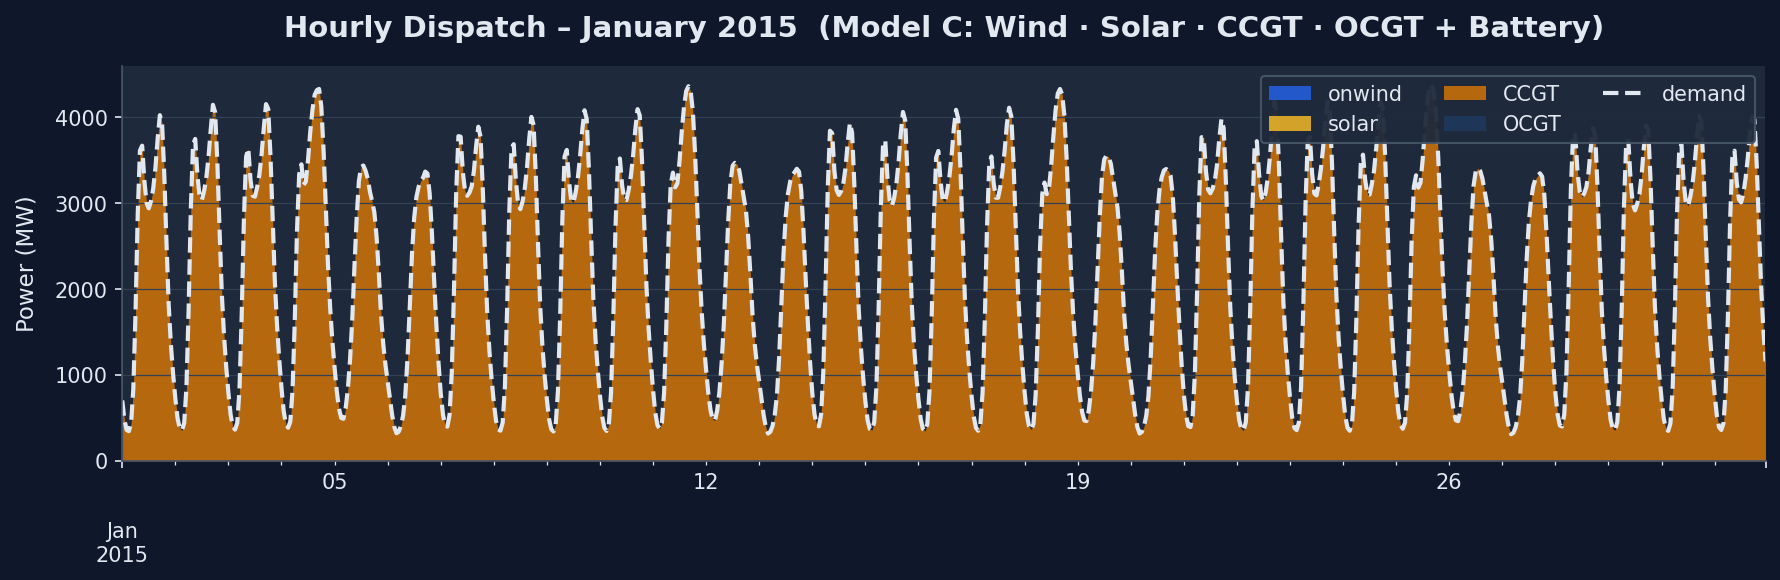

In [46]:
fig, ax = plt.subplots(figsize=(12, 4))
dispatch = n.generators_t.p.loc["2015-01"]
_pref = ["onwind", "solar", "CCGT", "OCGT"]
col_order = [c for c in _pref if c in dispatch.columns]
col_order += [c for c in dispatch.columns if c not in col_order]
colors = [TECH_COLORS.get(c, "#888888") for c in col_order]
dispatch[col_order].plot.area(ax=ax, color=colors, alpha=0.82, linewidth=0)
n.loads_t.p_set.loc["2015-01"].plot(
    ax=ax, color=TECH_COLORS["demand"], linewidth=2, linestyle="--", label="Demand"
)
ax.set_title("Hourly Dispatch – January 2015  (Model C: Wind · Solar · CCGT · OCGT + Battery)")
ax.set_ylabel("Power (MW)")
ax.set_xlabel("")
ax.legend(loc="upper right", ncol=3)
fig.tight_layout()
plt.show()


We can also plot the charging and discharging of the battery

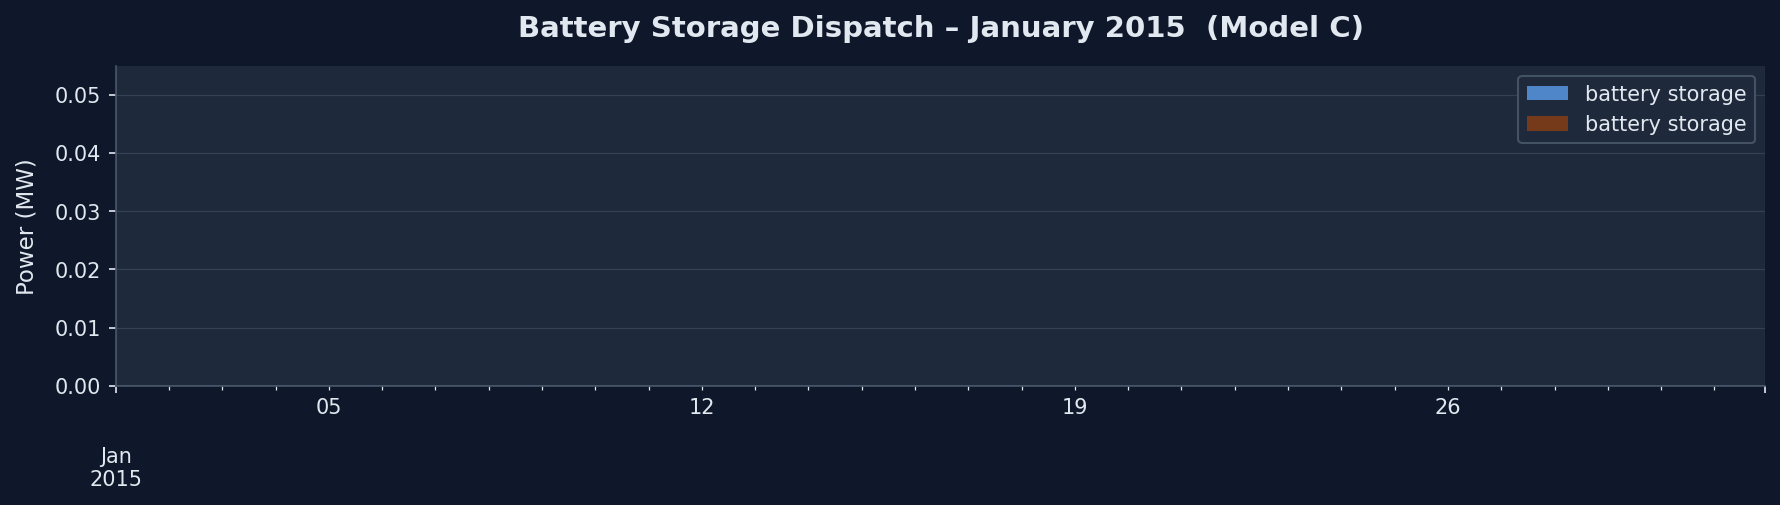

In [47]:
fig, ax = plt.subplots(figsize=(12, 3.5))
batt = n.storage_units_t.p.loc["2015-01"]
batt.clip(lower=0).plot.area(
    ax=ax, color=TECH_COLORS["battery storage"], alpha=0.75, linewidth=0, label="Discharging"
)
batt.clip(upper=0).plot.area(
    ax=ax, color=AMBER["dark"], alpha=0.75, linewidth=0, label="Charging"
)
ax.axhline(0, color=SPINE, linewidth=0.8)
ax.set_title("Battery Storage Dispatch – January 2015  (Model C)")
ax.set_ylabel("Power (MW)")
ax.set_xlabel("")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


and the demand time series

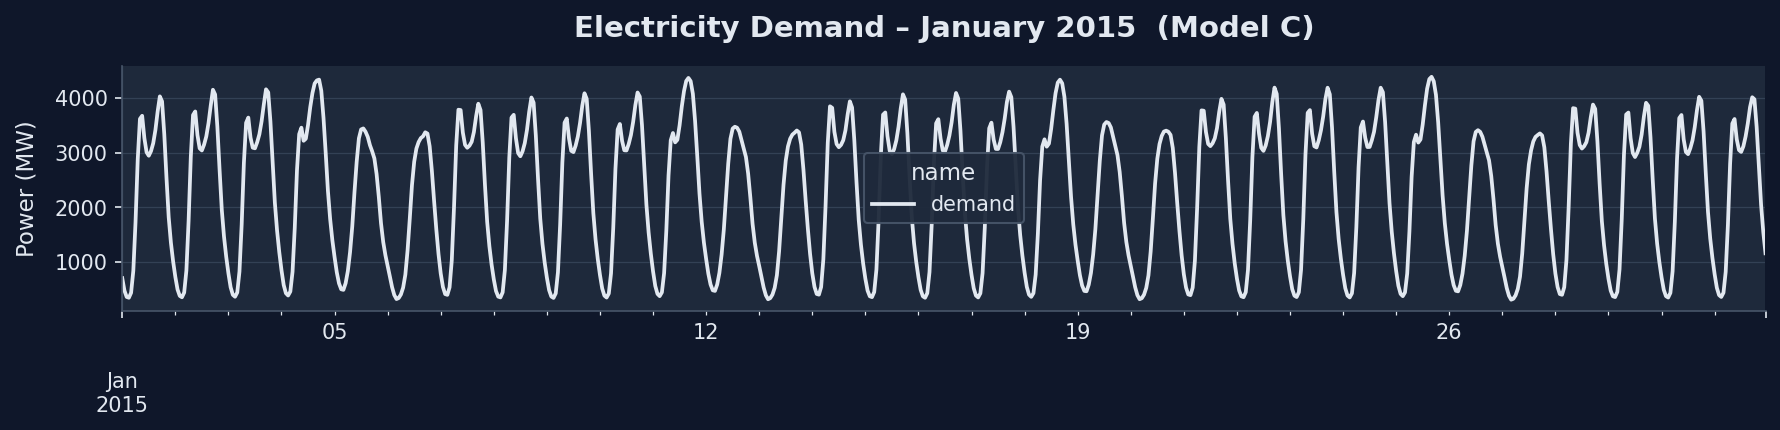

In [48]:
fig, ax = plt.subplots(figsize=(12, 3))
n.loads_t.p.loc["2015-01"].plot(ax=ax, color=TECH_COLORS["demand"], linewidth=1.8)
ax.set_title("Electricity Demand – January 2015  (Model C)")
ax.set_ylabel("Power (MW)")
ax.set_xlabel("")
fig.tight_layout()
plt.show()


**d) How does the CCGT power plant recover its cost?**

To calculate the revenues collected by every technology, for every generator, we multiply the energy generated in very hour by the electricity price in that hour and sum for the entire year.

In [49]:
n.generators_t.p.multiply(n.buses_t.marginal_price.to_numpy()).sum().div(1e6) # EUR -> MEUR

name
OCGT        0.00000
onwind      0.00000
solar       0.00000
CCGT      109.10867
dtype: float64

This corresponds to the total cost for every technology, which we can also read using the statistics module:

In [50]:
(n.statistics.capex() + n.statistics.opex()).div(1e6)

component  carrier
Generator  CCGT       902.758062
dtype: float64

The CCGT does not recover its full cost. This is to be expected because its capacity was not optimized but set exogenously 

**e) How does the battery recover its cost?**

The battery capacity is also co-optimized with the dispatch, so it exactly recovers its cost by buying electricity when the price is low and selling when it is high. The revenues from market can be calculated by multiplying the battery charging and discharging by the electricity price time series

In [51]:
n.storage_units_t.p.multiply(n.buses_t.marginal_price.to_numpy()).sum().div(1e6) # EUR -> MEUR

name
battery storage    0.0
dtype: float64

The market revenues exactly correspons with the total battery costs

In [52]:
n.storage_units.p_nom_opt*(costs.at["battery inverter", "capital_cost"]+ 2 * costs.at["battery storage", "capital_cost"])/(1e6)# EUR -> MEUR

name
battery storage   -0.0
Name: p_nom_opt, dtype: float64